In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv


In [2]:
#Step_1 : Data Loading
input_path = '/kaggle/input/datasets/andrewmvd/fetal-health-classification/fetal_health.csv'

#making a dataframe of the input
df =pd.read_csv(input_path)

print (df.head())

   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

/tmp/ipykernel_24/1539057873.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fetal_health', palette='mako')


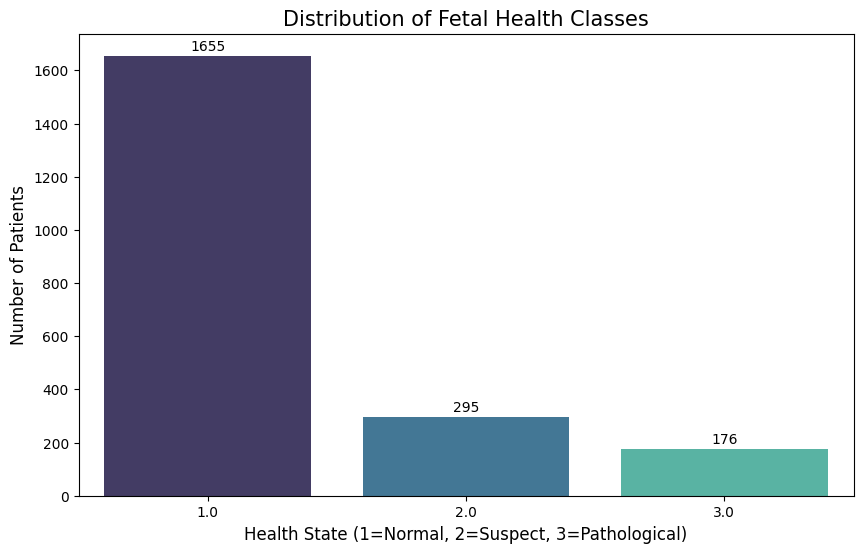

Clinical Distribution (%) :
fetal_health
1.0    77.85
2.0    13.88
3.0     8.28
Name: proportion, dtype: float64


In [3]:
#Step_2: Plotting the data and analysing
import matplotlib.pyplot as plt
import seaborn as sns

#1.0 = Normal | 2.0 = Suspect | 3.0 = Pathological
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='fetal_health', palette='mako')

plt.title('Distribution of Fetal Health Classes', fontsize=15)
plt.xlabel('Health State (1=Normal, 2=Suspect, 3=Pathological)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Adding the exact counts on top of the bars for clarity
for i in range(len(df['fetal_health'].value_counts())):
    count = df['fetal_health'].value_counts().iloc[i]
    plt.text(i, count + 10, str(count), ha='center', va='bottom')

plt.show()

# Print the mathematical imbalance
print("Clinical Distribution (%) :")
print(round(df['fetal_health'].value_counts(normalize=True) * 100, 2))